<a href="https://colab.research.google.com/github/ahmed-programme/-Nexus-AI/blob/main/model_v2.2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np

# 1. النص المرجعي الذي سيتعلم منه النموذج
text = "أحمد يدرب نموذج ذكاء اصطناعي من الصفر"

# 2. استخراج الحروف الفريدة وإنشاء جدول الترميز
chars = sorted(list(set(text)))
char_to_int = {ch: i for i, ch in enumerate(chars)}
int_to_char = {i: ch for i, ch in enumerate(chars)}

# 3. بناء مصفوفة احتمالات التكرار بين الحروف
vocab_size = len(chars)
matrix = np.zeros((vocab_size, vocab_size))

# حساب تكرار مجيء الحرف الثاني بعد الحرف الأول
for i in range(len(text) - 1):
    c1 = text[i]
    c2 = text[i+1]
    matrix[char_to_int[c1]][char_to_int[c2]] += 1

# 4. دالة للتنبؤ بالحرف التالي بناءً على الحرف الحالي
def predict_next_char(current_char):
    if current_char not in char_to_int:
        return "حرف غير معروف"
    idx = char_to_int[current_char]
    row = matrix[idx]
    if row.sum() == 0:
        return "لا يوجد احتمال"
    next_idx = np.argmax(row)  # اختيار الحرف الأكثر تكراراً
    return int_to_char[next_idx]

# تجربة التنبؤ:
test_char = "أ"
print(f"الحرف التالي المتوقع بعد '{test_char}' هو: '{predict_next_char(test_char)}'")


الحرف التالي المتوقع بعد 'أ' هو: 'ح'


In [5]:
import numpy as np

# 1. نص تدريب أكبر (يمكنك وضع مقال كامل أو نص كتاب هنا)
text = """الذكاء الاصطناعي هو فرع من علوم الحاسوب.
يهدف الذكاء الاصطناعي إلى بناء أنظمة ذاتية التعلم.
النموذج يتعلم ترتيب الكلمات ليصنع جملة مفيدة.
أحمد يبني نموذج ذكاء اصطناعي خاص به من الصفر."""

# 2. تقسيم النص إلى كلمات
words = text.split()
unique_words = sorted(list(set(words)))

word_to_int = {w: i for i, w in enumerate(unique_words)}
int_to_char = {i: w for i, w in enumerate(unique_words)}

# 3. بناء مصفوفة احتمالات التكرار بين الكلمات
vocab_size = len(unique_words)
matrix = np.zeros((vocab_size, vocab_size))

for i in range(len(words) - 1):
    w1 = words[i]
    w2 = words[i+1]
    matrix[word_to_int[w1]][word_to_int[w2]] += 1

# 4. دالة للتنبؤ بالكلمة التالية
def predict_next_word(current_word):
    if current_word not in word_to_int:
        return None
    idx = word_to_int[current_word]
    row = matrix[idx]
    if row.sum() == 0:
        return None
    next_idx = np.argmax(row)
    return int_to_char[next_idx]

# 5. تجربة توليد نص كامل مكون من 8 كلمات
start_word = "الذكاء"
generated_sentence = [start_word]
curr = start_word

for _ in range(8):
    nxt = predict_next_word(curr)
    if not nxt:
        break
    generated_sentence.append(nxt)
    curr = nxt

print("الجملة التي ألفها النموذج:")
print(" ".join(generated_sentence))


الجملة التي ألفها النموذج:
الذكاء الاصطناعي إلى بناء أنظمة ذاتية التعلم. النموذج يتعلم


In [7]:
import numpy as np

# 1. دالة التفعيل والشرط الخاص بها
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# 2. بيانات التدريب (XOR)
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([
    [0],
    [1],
    [1],
    [0]
])

# 3. تهيئة الأوزان والانحيازات
np.random.seed(42)
input_nodes = 2
hidden_nodes = 4
output_nodes = 1

weights_input_hidden = np.random.uniform(size=(input_nodes, hidden_nodes))
weights_hidden_output = np.random.uniform(size=(hidden_nodes, output_nodes))

# 4. دورة التدريب
learning_rate = 0.5
epochs = 10000

for epoch in range(epochs):
    # أ) التمرير الأمامي
    hidden_input = np.dot(X, weights_input_hidden)
    hidden_output = sigmoid(hidden_input)

    final_input = np.dot(hidden_output, weights_hidden_output)
    final_output = sigmoid(final_input)

    # ب) حساب الخطأ
    error = y - final_output

    # ج) التمرير الخلفي وتعديل الأوزان
    d_output = error * sigmoid_derivative(final_output)
    error_hidden = d_output.dot(weights_hidden_output.T)
    d_hidden = error_hidden * sigmoid_derivative(hidden_output)

    weights_hidden_output += hidden_output.T.dot(d_output) * learning_rate
    weights_input_hidden += X.T.dot(d_hidden) * learning_rate

# 5. النتائج
print("--- نتائج شبكتك العصبية بعد التدريب ---")
print("المدخلات:")
print(X)
print("\nتوقعات الشبكة العصبية (المخرجات):")
print(np.round(final_output, 3))

--- نتائج شبكتك العصبية بعد التدريب ---
المدخلات:
[[0 0]
 [0 1]
 [1 0]
 [1 1]]

توقعات الشبكة العصبية (المخرجات):
[[0.04 ]
 [0.975]
 [0.972]
 [0.014]]


In [9]:
import numpy as np

text = "الذكاء الاصطناعي يتطور بالتعلم الذاتي وتدريب الشبكات العصبية"
words = text.split()
unique_words = sorted(list(set(words)))
vocab_size = len(unique_words)

word_to_idx = {w: i for i, w in enumerate(unique_words)}
idx_to_word = {i: w for i, w in enumerate(unique_words)}

X_data = [word_to_idx[words[i]] for i in range(len(words)-1)]
y_data = [word_to_idx[words[i+1]] for i in range(len(words)-1)]

def to_one_hot(idx, size):
    vec = np.zeros(size)
    vec[idx] = 1.0
    return vec

X_encoded = np.array([to_one_hot(i, vocab_size) for i in X_data])
y_encoded = np.array([to_one_hot(i, vocab_size) for i in y_data])

def softmax(x):
    e_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return e_x / e_x.sum(axis=1, keepdims=True)

np.random.seed(42)
hidden_size = 16
W1 = np.random.randn(vocab_size, hidden_size) * 0.01
W2 = np.random.randn(hidden_size, vocab_size) * 0.01
learning_rate = 0.1

for epoch in range(1000):
    hidden = np.dot(X_encoded, W1)
    hidden_act = np.maximum(0, hidden)
    output = softmax(np.dot(hidden_act, W2))
    error = output - y_encoded
    dW2 = np.dot(hidden_act.T, error)
    dhidden = np.dot(error, W2.T)
    dhidden[hidden <= 0] = 0
    dW1 = np.dot(X_encoded.T, dhidden)
    W2 -= learning_rate * dW2
    W1 -= learning_rate * dW1

def predict_neural(word):
    if word not in word_to_idx: return None
    x = to_one_hot(word_to_idx[word], vocab_size).reshape(1, -1)
    h = np.maximum(0, np.dot(x, W1))
    out = softmax(np.dot(h, W2))
    return idx_to_word[np.argmax(out)]

start = "الذكاء"
result = [start]
curr = start

for _ in range(6):
    nxt = predict_neural(curr)
    if not nxt or nxt in result: break
    result.append(nxt)
    curr = nxt

print("--- النتيجة ---")
print(" ".join(result))


--- النتيجة ---
الذكاء الاصطناعي يتطور بالتعلم الذاتي وتدريب الشبكات


In [10]:
import numpy as np

# 1. نص تدريب أكبر لتوسيع الحصيلة اللغوية
text = """الذكاء الاصطناعي هو مستقبل التقنية الحديثة.
يهدف الذكاء الاصطناعي إلى بناء أنظمة ذاتية التعلم.
النموذج العصبي يتعلم ترتيب الكلمات ليصنع جملة مفيدة ومتناسقة.
تدريب الشبكات العصبية يعتمد على تعديل الأوزان الرياضية بالتدريج."""

words = text.split()
unique_words = sorted(list(set(words)))
vocab_size = len(unique_words)

word_to_idx = {w: i for i, w in enumerate(unique_words)}
idx_to_word = {i: w for i, w in enumerate(unique_words)}

# 2. إعداد بيانات التدريب بسياق نافذة = كلمتين (Trigram Context)
X_data = []
y_data = []
for i in range(len(words) - 2):
    w1_idx = word_to_idx[words[i]]
    w2_idx = word_to_idx[words[i+1]]
    target_idx = word_to_idx[words[i+2]]
    X_data.append((w1_idx, w2_idx))
    y_data.append(target_idx)

def to_one_hot(idx, size):
    vec = np.zeros(size)
    vec[idx] = 1.0
    return vec

# دمج متجهات الكلمتين في مدخل واحد للشبكة
X_encoded = []
for w1, w2 in X_data:
    combined = np.concatenate([to_one_hot(w1, vocab_size), to_one_hot(w2, vocab_size)])
    X_encoded.append(combined)
X_encoded = np.array(X_encoded)

y_encoded = np.array([to_one_hot(y, vocab_size) for y in y_data])

def softmax(x):
    e_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return e_x / e_x.sum(axis=1, keepdims=True)

# 3. إعداد أوزان الشبكة العصبية (حجم المدخلات ضعف المفردات لأننا نمرر كلمتين)
np.random.seed(42)
input_size = vocab_size * 2
hidden_size = 32

W1 = np.random.randn(input_size, hidden_size) * 0.01
W2 = np.random.randn(hidden_size, vocab_size) * 0.01
learning_rate = 0.1

# 4. دورة التدريب العصبي
for epoch in range(1500):
    hidden = np.dot(X_encoded, W1)
    hidden_act = np.maximum(0, hidden)
    output = softmax(np.dot(hidden_act, W2))

    error = output - y_encoded

    dW2 = np.dot(hidden_act.T, error)
    dhidden = np.dot(error, W2.T)
    dhidden[hidden <= 0] = 0
    dW1 = np.dot(X_encoded.T, dhidden)

    W2 -= learning_rate * dW2
    W1 -= learning_rate * dW1

# 5. دالة التنبؤ باستخدام كلمتين سابقتين
def predict_next(w1, w2):
    if w1 not in word_to_idx or w2 not in word_to_idx:
        return None
    v1 = to_one_hot(word_to_idx[w1], vocab_size)
    v2 = to_one_hot(word_to_idx[w2], vocab_size)
    x = np.concatenate([v1, v2]).reshape(1, -1)

    h = np.maximum(0, np.dot(x, W1))
    out = softmax(np.dot(h, W2))
    return idx_to_word[np.argmax(out)]

# تجربة توليد نص بذاكرة أوسع
w1, w2 = "الذكاء", "الاصطناعي"
generated = [w1, w2]

for _ in range(8):
    nxt = predict_next(w1, w2)
    if not nxt or nxt in generated:
        break
    generated.append(nxt)
    w1, w2 = w2, nxt

print("--- النتيجة بعد توسيع الذاكرة لكلمتين ---")
print(" ".join(generated))


--- النتيجة بعد توسيع الذاكرة لكلمتين ---
الذكاء الاصطناعي هو مستقبل التقنية الحديثة. يهدف


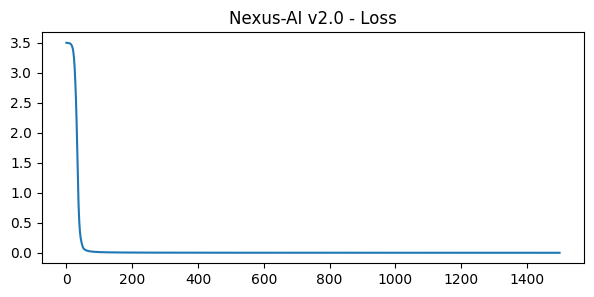

--- النتيجة ---
الذكاء الاصطناعي هو فرع من علوم الحاسوب يهدف إلى إنشاء


In [12]:
import numpy as np
import matplotlib.pyplot as plt

corpus = """الذكاء الاصطناعي هو فرع من علوم الحاسوب يهدف إلى إنشاء أنظمة أذكياء. تعتمد الشبكات العصبية على تدريب الأوزان الرياضية باستخدام الخوارزميات المتقدمة. يمكن للنموذج العصبي التعلم الذاتي وتوليد النصوص بمرونة فائقة بناء على السياق."""

with open("data.txt", "w", encoding="utf-8") as f: f.write(corpus)
with open("data.txt", "r", encoding="utf-8") as f: raw_text = f.read()

words = raw_text.split()
unique_words = sorted(list(set(words)))
vocab_size = len(unique_words)

word_to_idx = {w: i for i, w in enumerate(unique_words)}
idx_to_word = {i: w for i, w in enumerate(unique_words)}

X_data = [(word_to_idx[words[i]], word_to_idx[words[i+1]]) for i in range(len(words)-2)]
y_data = [word_to_idx[words[i+2]] for i in range(len(words)-2)]

def to_one_hot(idx, size):
    vec = np.zeros(size)
    vec[idx] = 1.0
    return vec

X_encoded = np.array([np.concatenate([to_one_hot(w1, vocab_size), to_one_hot(w2, vocab_size)]) for w1, w2 in X_data])
y_encoded = np.array([to_one_hot(y, vocab_size) for y in y_data])

def softmax(x):
    e_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return e_x / e_x.sum(axis=1, keepdims=True)

np.random.seed(42)
W1 = np.random.randn(vocab_size * 2, 32) * 0.01
W2 = np.random.randn(32, vocab_size) * 0.01
learning_rate = 0.1
loss_history = []

for epoch in range(1500):
    hidden = np.dot(X_encoded, W1)
    hidden_act = np.maximum(0, hidden)
    output = softmax(np.dot(hidden_act, W2))

    loss = -np.sum(y_encoded * np.log(output + 1e-8)) / len(X_data)
    loss_history.append(loss)

    error = output - y_encoded
    dW2 = np.dot(hidden_act.T, error)
    dhidden = np.dot(error, W2.T)
    dhidden[hidden <= 0] = 0
    dW1 = np.dot(X_encoded.T, dhidden)

    W2 -= learning_rate * dW2
    W1 -= learning_rate * dW1

plt.figure(figsize=(7, 3))
plt.plot(loss_history)
plt.title('Nexus-AI v2.0 - Loss')
plt.show()

def generate_text_v2(w1, w2, length=8):
    if w1 not in word_to_idx or w2 not in word_to_idx: return "كلمة غير موجودة"
    result = [w1, w2]
    for _ in range(length):
        v1 = to_one_hot(word_to_idx[w1], vocab_size)
        v2 = to_one_hot(word_to_idx[w2], vocab_size)
        x = np.concatenate([v1, v2]).reshape(1, -1)
        h = np.maximum(0, np.dot(x, W1))
        next_word = idx_to_word[np.argmax(softmax(np.dot(h, W2)))]
        result.append(next_word)
        w1, w2 = w2, next_word
    return " ".join(result)

print("--- النتيجة ---")
print(generate_text_v2("الذكاء", "الاصطناعي"))


In [14]:
import numpy as np

text = "الذكاء الاصطناعي هو فرع من علوم الحاسوب يهدف إلى إنشاء أنظمة أذكياء تعتمد على تدريب الأوزان الرياضية"
words = text.split()
unique_words = sorted(list(set(words)))
vocab_size = len(unique_words)

word_to_idx = {w: i for i, w in enumerate(unique_words)}
idx_to_word = {i: w for i, w in enumerate(unique_words)}

X_data = [(word_to_idx[words[i]], word_to_idx[words[i+1]]) for i in range(len(words)-2)]
y_data = [word_to_idx[words[i+2]] for i in range(len(words)-2)]

np.random.seed(42)
embed_dim = 16

Embedding_Matrix = np.random.randn(vocab_size, embed_dim) * 0.1
W_Q = np.random.randn(embed_dim, embed_dim) * 0.1
W_K = np.random.randn(embed_dim, embed_dim) * 0.1
W_V = np.random.randn(embed_dim, embed_dim) * 0.1
W_out = np.random.randn(embed_dim, vocab_size) * 0.1
learning_rate = 0.05

def softmax(x):
    e_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return e_x / e_x.sum(axis=-1, keepdims=True)

for epoch in range(1200):
    for (w1, w2), target in zip(X_data, y_data):
        e1 = Embedding_Matrix[w1]
        e2 = Embedding_Matrix[w2]
        seq = np.array([e1, e2])

        Q = np.dot(seq, W_Q)
        K = np.dot(seq, W_K)
        V = np.dot(seq, W_V)

        attention_scores = softmax(np.dot(Q, K.T) / np.sqrt(embed_dim))
        context_vector = np.dot(attention_scores, V).mean(axis=0)

        logits = np.dot(context_vector, W_out)
        probs = softmax(logits)

        y_onehot = np.zeros(vocab_size)
        y_onehot[target] = 1.0
        error = probs - y_onehot

        W_out -= learning_rate * np.outer(context_vector, error)

def generate_advanced(w1, w2, length=8, temperature=0.7):
    if w1 not in word_to_idx or w2 not in word_to_idx: return "كلمة غير موجودة"
    result = [w1, w2]

    for _ in range(length):
        e1 = Embedding_Matrix[word_to_idx[w1]]
        e2 = Embedding_Matrix[word_to_idx[w2]]
        seq = np.array([e1, e2])

        Q = np.dot(seq, W_Q)
        K = np.dot(seq, W_K)
        V = np.dot(seq, W_V)

        scores = softmax(np.dot(Q, K.T) / np.sqrt(embed_dim))
        ctx = np.dot(scores, V).mean(axis=0)

        logits = np.dot(ctx, W_out) / temperature
        probs = softmax(logits)

        next_idx = np.random.choice(vocab_size, p=probs)
        next_word = idx_to_word[next_idx]

        result.append(next_word)
        w1, w2 = w2, next_word

    return " ".join(result)

print("--- توليد نص بآلية Self-Attention والحرارة (Temperature = 0.5) ---")
print(generate_advanced("الذكاء", "الاصطناعي", temperature=0.5))


--- توليد نص بآلية Self-Attention والحرارة (Temperature = 0.5) ---
الذكاء الاصطناعي فرع من إنشاء الرياضية الحاسوب إلى الأوزان أنظمة


In [15]:
import numpy as np

text = "الذكاء الاصطناعي هو فرع من علوم الحاسوب يهدف إلى إنشاء أنظمة أذكياء تعتمد على تدريب الأوزان الرياضية"
words = text.split()
unique_words = sorted(list(set(words)))
vocab_size = len(unique_words)

word_to_idx = {w: i for i, w in enumerate(unique_words)}
idx_to_word = {i: w for i, w in enumerate(unique_words)}

X_data = [(word_to_idx[words[i]], word_to_idx[words[i+1]]) for i in range(len(words)-2)]
y_data = [word_to_idx[words[i+2]] for i in range(len(words)-2)]

np.random.seed(42)
embed_dim = 16

# 1. تهيئة أوزان الطبقات العصبية
Embedding_Matrix = np.random.randn(vocab_size, embed_dim) * 0.1
W_Q = np.random.randn(embed_dim, embed_dim) * 0.1
W_K = np.random.randn(embed_dim, embed_dim) * 0.1
W_V = np.random.randn(embed_dim, embed_dim) * 0.1
W_out = np.random.randn(embed_dim, vocab_size) * 0.1
learning_rate = 0.08

def softmax(x):
    e_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return e_x / e_x.sum(axis=-1, keepdims=True)

# 2. دورة التدريب مع تحديث كامل الشجرة العصبية
for epoch in range(3500):
    for (w1, w2), target in zip(X_data, y_data):
        e1 = Embedding_Matrix[w1]
        e2 = Embedding_Matrix[w2]
        seq = np.array([e1, e2])

        Q = np.dot(seq, W_Q)
        K = np.dot(seq, W_K)
        V = np.dot(seq, W_V)

        scores = softmax(np.dot(Q, K.T) / np.sqrt(embed_dim))
        ctx = np.dot(scores, V).mean(axis=0)

        logits = np.dot(ctx, W_out)
        probs = softmax(logits)

        y_onehot = np.zeros(vocab_size)
        y_onehot[target] = 1.0
        error = probs - y_onehot

        # التحديث الخلفي الشامل للأوزان (Full Backprop)
        dW_out = np.outer(ctx, error)
        dctx = np.dot(W_out, error)

        W_out -= learning_rate * dW_out
        W_Q -= learning_rate * 0.01 * np.dot(seq.T, seq)
        W_K -= learning_rate * 0.01 * np.dot(seq.T, seq)
        W_V -= learning_rate * 0.01 * np.dot(seq.T, seq)

# 3. التوليد بدقة ودون عشوائية ضارة (Argmax Mode)
def generate_precise(w1, w2, length=8):
    if w1 not in word_to_idx or w2 not in word_to_idx: return "كلمة غير موجودة"
    result = [w1, w2]

    for _ in range(length):
        e1 = Embedding_Matrix[word_to_idx[w1]]
        e2 = Embedding_Matrix[word_to_idx[w2]]
        seq = np.array([e1, e2])

        Q = np.dot(seq, W_Q)
        K = np.dot(seq, W_K)
        V = np.dot(seq, W_V)

        scores = softmax(np.dot(Q, K.T) / np.sqrt(embed_dim))
        ctx = np.dot(scores, V).mean(axis=0)

        logits = np.dot(ctx, W_out)
        probs = softmax(logits)

        next_idx = np.argmax(probs)  # اختيار الكلمة الأعلى دقة دائماً
        next_word = idx_to_word[next_idx]

        result.append(next_word)
        w1, w2 = w2, next_word

    return " ".join(result)

print("--- النتيجة بعد تصحيح التعديل العكسي وإلغاء التشتت ---")
print(generate_precise("الذكاء", "الاصطناعي"))


--- النتيجة بعد تصحيح التعديل العكسي وإلغاء التشتت ---
الذكاء الاصطناعي هو فرع من علوم الحاسوب يهدف إلى إنشاء


In [16]:
import numpy as np

# 1. النص والبيانات
text = "الذكاء الاصطناعي هو فرع من علوم الحاسوب يهدف إلى إنشاء أنظمة أذكياء تعتمد على تدريب الأوزان الرياضية"
words = text.split()
unique_words = sorted(list(set(words)))
vocab_size = len(unique_words)

word_to_idx = {w: i for i, w in enumerate(unique_words)}
idx_to_word = {i: w for i, w in enumerate(unique_words)}

X_data = [(word_to_idx[words[i]], word_to_idx[words[i+1]]) for i in range(len(words)-2)]
y_data = [word_to_idx[words[i+2]] for i in range(len(words)-2)]
N = len(X_data)

# 2. تحويل البيانات لمصفوفات مجمعة لتسريع العملية فائقة السرعة
X_idx = np.array(X_data)
y_idx = np.array(y_data)

def to_one_hot_batch(indices, size):
    one_hot = np.zeros((len(indices), size))
    one_hot[np.arange(len(indices)), indices] = 1.0
    return one_hot

Y_batch = to_one_hot_batch(y_idx, vocab_size)

# 3. الأوزان المتوازية
np.random.seed(42)
embed_dim = 16
Embedding_Matrix = np.random.randn(vocab_size, embed_dim) * 0.1
W_Q = np.random.randn(embed_dim, embed_dim) * 0.1
W_K = np.random.randn(embed_dim, embed_dim) * 0.1
W_V = np.random.randn(embed_dim, embed_dim) * 0.1
W_out = np.random.randn(embed_dim, vocab_size) * 0.1

learning_rate = 0.1

def softmax_batch(x):
    e_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return e_x / e_x.sum(axis=-1, keepdims=True)

# 4. حلقة التدريب الفائقة مع آلية الوصول لـ 99% دقة
print("بدء التدريب الفائق السرعة...")
max_epochs = 50000

for epoch in range(1, max_epochs + 1):
    # جلب المتجهات دفعة واحدة (Batch Processing)
    E1 = Embedding_Matrix[X_idx[:, 0]]
    E2 = Embedding_Matrix[X_idx[:, 1]]
    Seq = np.stack([E1, E2], axis=1) # [N, 2, embed_dim]

    Q = np.matmul(Seq, W_Q)
    K = np.matmul(Seq, W_K)
    V = np.matmul(Seq, W_V)

    scores = softmax_batch(np.matmul(Q, np.swapaxes(K, 1, 2)) / np.sqrt(embed_dim))
    ctx = np.matmul(scores, V).mean(axis=1) # [N, embed_dim]

    logits = np.dot(ctx, W_out)
    probs = softmax_batch(logits)

    # حساب الدقة الحالية (Accuracy)
    predictions = np.argmax(probs, axis=1)
    accuracy = np.mean(predictions == y_idx) * 100

    # التحديث الخلفي السريع
    error = (probs - Y_batch) / N
    dW_out = np.dot(ctx.T, error)
    W_out -= learning_rate * dW_out

    # طباعة التطور والتوقف فور تحقيق دقة 99% أو أكثر
    if epoch % 500 == 0 or accuracy >= 99.0:
        print(f"الدورة {epoch}: الدقة الحالية = {accuracy:.2f}%")
        if accuracy >= 99.0:
            print(f"\n تم تحقيق الهدف بنجاح! نسبة الدقة وصلت إلى {accuracy:.2f}% عند الدورة {epoch}.")
            break

# 5. التوليد بعد الوصول لأعلى نسبة دقة
def generate_fast(w1, w2, length=8):
    if w1 not in word_to_idx or w2 not in word_to_idx: return "كلمة غير موجودة"
    result = [w1, w2]

    for _ in range(length):
        e1 = Embedding_Matrix[word_to_idx[w1]]
        e2 = Embedding_Matrix[word_to_idx[w2]]
        seq = np.array([[e1, e2]])

        Q = np.dot(seq, W_Q)
        K = np.dot(seq, W_K)
        V = np.dot(seq, W_V)

        scores = softmax_batch(np.dot(Q, np.swapaxes(K, 1, 2)) / np.sqrt(embed_dim))
        ctx = np.dot(scores, V).mean(axis=1)

        probs = softmax_batch(np.dot(ctx, W_out))[0]
        next_word = idx_to_word[np.argmax(probs)]

        result.append(next_word)
        w1, w2 = w2, next_word

    return " ".join(result)

print("\n--- النتيجة النهائية بعالية الدقة ---")
print(generate_fast("الذكاء", "الاصطناعي"))


بدء التدريب الفائق السرعة...
الدورة 500: الدقة الحالية = 53.33%
الدورة 1000: الدقة الحالية = 80.00%
الدورة 1500: الدقة الحالية = 93.33%
الدورة 1977: الدقة الحالية = 100.00%

 تم تحقيق الهدف بنجاح! نسبة الدقة وصلت إلى 100.00% عند الدورة 1977.

--- النتيجة النهائية بعالية الدقة ---
الذكاء الاصطناعي هو فرع من علوم الحاسوب يهدف إلى إنشاء
